In [1]:
import getpass
import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "finance-agent"

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("ANTHROPIC_API_KEY")
_set_if_undefined("TAVILY_API_KEY")
_set_if_undefined("LANGSMITH_API_KEY")

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearch(max_results=5)

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

<>:24: SyntaxWarning: invalid escape sequence '\`'
<>:24: SyntaxWarning: invalid escape sequence '\`'
<>:24: SyntaxWarning: invalid escape sequence '\`'
<>:24: SyntaxWarning: invalid escape sequence '\`'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_47108\792484784.py:24: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\Administrator\AppData\Local\Temp\ipykernel_47108\792484784.py:24: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\Administrator\AppData\Local\Temp\ipykernel_47108\792484784.py:5: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [3]:
def make_llm():
    return ChatAnthropic(
        model_name="deepseek-v4-pro",
        temperature=0,
        base_url="https://api.deepseek.com/anthropic",
        #thinking={"type":"disabled"}
    )

In [4]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [5]:
def extract_text(content):
    """从 content 提取纯文本，丢弃 thinking 等块。"""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        texts = []
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text":
                texts.append(block.get("text", ""))
            elif isinstance(block, str):
                texts.append(block)
        return "\n".join(texts)
    return str(content)

In [6]:
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command
from typing import Literal

llm = make_llm()


def get_next_node_by_text(text, goto):
    return END if "FINAL ANSWER" in text else goto


# Research agent and node
research_agent = create_agent(
    llm,
    tools=[tavily_tool],
    system_prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)


def research_node(
    state: MessagesState,
) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)
    inspect_result(result)                      # 截断长文本，看结构

    text=extract_text(result["messages"][-1].content)
    goto = get_next_node_by_text(text, "chart_generator")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=text, name="researcher"
    )
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


# Chart generator agent and node
# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION, WHICH CAN BE UNSAFE WHEN NOT SANDBOXED
chart_agent = create_agent(
    llm,
    [python_repl_tool],
    system_prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)


def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)
    text=extract_text(result["messages"][-1].content)
    goto = get_next_node_by_text(text, "researcher")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=text, name="chart_generator"
    )
    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


In [7]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()

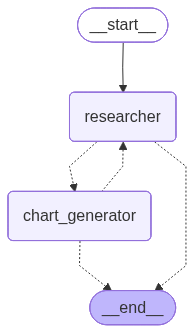

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [15]:
def inspect_keys(s, max_val=80):
    """
    展示每条消息的【所有字段键】，值缩略。
    用 model_dump() 拿全部字段，再缩略值，方便对照 LangSmith 看结构。
    """
    BAR = "=" * 72
    for node_name, update in s.items():
        print(BAR)
        print(f" 节点: {node_name}")
        print(BAR)
        messages = update.get("messages", []) if isinstance(update, dict) else []
        for i, msg in enumerate(messages):
            print(f"\n[{i}] {type(msg).__name__}")
            print("-" * 72)
            # 把消息对象转成 dict（Pydantic 对象有 model_dump，拿到全部字段）
            d = msg.model_dump() if hasattr(msg, "model_dump") else dict(vars(msg))
            _walk(d, max_val=max_val)


def _walk(obj, indent=2, max_val=80):
    """递归遍历，打印所有键，值缩略。"""
    pad = " " * indent
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, dict):
                print(f"{pad}{k}:")
                _walk(v, indent + 4, max_val)
            elif isinstance(v, list):
                print(f"{pad}{k}: [list, {len(v)} 项]")
                # 列表里若是 dict（如 content 块、tool_calls），展开第一项的键结构
                for j, item in enumerate(v):
                    if isinstance(item, dict):
                        print(f"{pad}  [{j}]:")
                        _walk(item, indent + 6, max_val)
                    else:
                        print(f"{pad}  [{j}] {_short(item, max_val)}")
            else:
                print(f"{pad}{k}: {_short(v, max_val)}")
    else:
        print(f"{pad}{_short(obj, max_val)}")


def _short(v, n=80):
    """值缩略：长字符串截断，标注类型。"""
    if v is None:
        return "None"
    s = repr(v).replace("\n", "\\n")
    if len(s) <= n:
        return s
    return s[:n] + f" …[{type(v).__name__}, 共{len(str(v))}字]"

 节点: researcher

[0] HumanMessage
------------------------------------------------------------------------
  content: "First, get the UK's GDP over the past 5 years, then make a line chart of it. On …[str, 共109字]
  additional_kwargs:
  response_metadata:
  type: 'human'
  name: None
  id: '5357f1ba-16fa-4173-ad82-8925d010d742'

[1] AIMessage
------------------------------------------------------------------------
  content: [list, 2 项]
    [0]:
        signature: '6e2fbd50-187f-40f1-83d5-bb97d7345d04'
        thinking: "The user wants me to:\n1. Research the UK's GDP over the past 5 years (so rough …[str, 共237字]
        type: 'thinking'
    [1]:
        id: 'call_00_7WVioSINUDaWH669PzFj2061'
        input:
            query: 'UK GDP annual data 2020 2021 2022 2023 2024'
            search_depth: 'advanced'
        name: 'tavily_search'
        type: 'tool_use'
  additional_kwargs:
  response_metadata:
      id: '6e2fbd50-187f-40f1-83d5-bb97d7345d04'
      container: None
      model: '

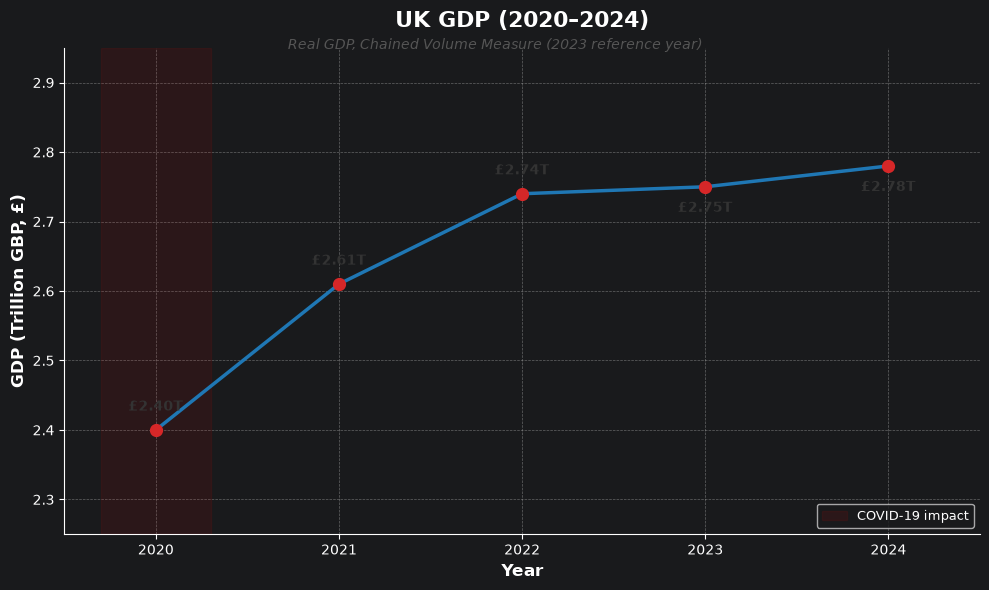

 节点: chart_generator

[0] HumanMessage
------------------------------------------------------------------------
  content: "First, get the UK's GDP over the past 5 years, then make a line chart of it. On …[str, 共109字]
  additional_kwargs:
  response_metadata:
  type: 'human'
  name: None
  id: '5357f1ba-16fa-4173-ad82-8925d010d742'

[1] AIMessage
------------------------------------------------------------------------
  content: [list, 2 项]
    [0]:
        signature: '6e2fbd50-187f-40f1-83d5-bb97d7345d04'
        thinking: "The user wants me to:\n1. Research the UK's GDP over the past 5 years (so rough …[str, 共237字]
        type: 'thinking'
    [1]:
        id: 'call_00_7WVioSINUDaWH669PzFj2061'
        input:
            query: 'UK GDP annual data 2020 2021 2022 2023 2024'
            search_depth: 'advanced'
        name: 'tavily_search'
        type: 'tool_use'
  additional_kwargs:
  response_metadata:
      id: '6e2fbd50-187f-40f1-83d5-bb97d7345d04'
      container: None
      mod

In [16]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "First, get the UK's GDP over the past 5 years, then make a line chart of it. "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    inspect_keys(s)